# Akomolafe Nathaniel Iyanuoluwa Data Science Unemployment Analysis with Python 
# This notebook analyzes the unemployment trends in India, focusing on the impact of COVID-19. It includes data loading, cleaning, and various visualizations to understand the unemployment patterns across different demographics and time periods.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from IPython.display import display, Markdown

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

Unemp_India = pd.read_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 2\Unemployment_in_India.csv")
Unemp_India.columns = [c.strip() for c in Unemp_India.columns]

display(Unemp_India.columns.to_frame(name='Column Names'))

display(Unemp_India.head())

,Column Names
Region,Region
Date,Date
Frequency,Frequency
Estimated Unemployment Rate (%),Estimated Unemployment Rate (%)
Estimated Employed,Estimated Employed
Estimated Labour Participation Rate (%),Estimated Labour Participation Rate (%)
Area,Area


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [2]:
# Shape
Unemp_India.shape

(768, 7)

In [3]:
# Null values
Unemp_India.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [4]:
# Striping whitespace from string columns
for c in Unemp_India.select_dtypes(include='object').columns:
    Unemp_India[c] = Unemp_India[c].str.strip()

# Droping fullynempty trailing rows and rows with null in key column
Unemp_India = Unemp_India.dropna(how='all')
Unemp_India = Unemp_India.dropna(subset=['Estimated Unemployment Rate (%)'])

Unemp_India['Date'] = pd.to_datetime(Unemp_India['Date'], format='%d-%m-%Y')

Unemp_India.dtypes

C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_4880\2651046126.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in Unemp_India.select_dtypes(include='object').columns:


Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object

In [5]:


display(Markdown("## Shape After Cleaning"))
display(Unemp_India.shape)

display(Markdown("## Remaining Null Values"))
display(Unemp_India.isnull().sum().to_frame("Null Count"))

display(Markdown("## Descriptive Statistics"))
display(Unemp_India.describe())

## Shape After Cleaning

(740, 7)

## Remaining Null Values

,Null Count
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


## Descriptive Statistics

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


**Observation:** 
The raw file contained 28 fully blank trailing rows, which were dropped. After cleaning, the dataset has no missing values across the core analysis columns.

In [6]:
# EDA for Region-wise & Month-wise Trends

region_avg = (
    Unemp_India.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

region_avg.head(10).to_frame('Average Unemployment Rate (%)')

,Average Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


In [7]:
month_avg = (
    Unemp_India.groupby(
        Unemp_India['Date'].dt.to_period('M')
    )['Estimated Unemployment Rate (%)']
    .mean()
)

month_avg.to_frame('Average Unemployment Rate (%)')

,Average Unemployment Rate (%)
Date,
2019-05,8.874259
2019-06,9.303333
2019-07,9.033889
2019-08,9.637925
2019-09,9.051731
2019-10,9.900909
2019-11,9.868364
2019-12,9.497358
2020-01,9.950755


**Observation:** Unemployment rates stay relatively stable and low through 2019, then spike dramatically starting March/April 2020 directly coinciding with India's nationwide COVID-19 lockdown (announced 25 March 2020).

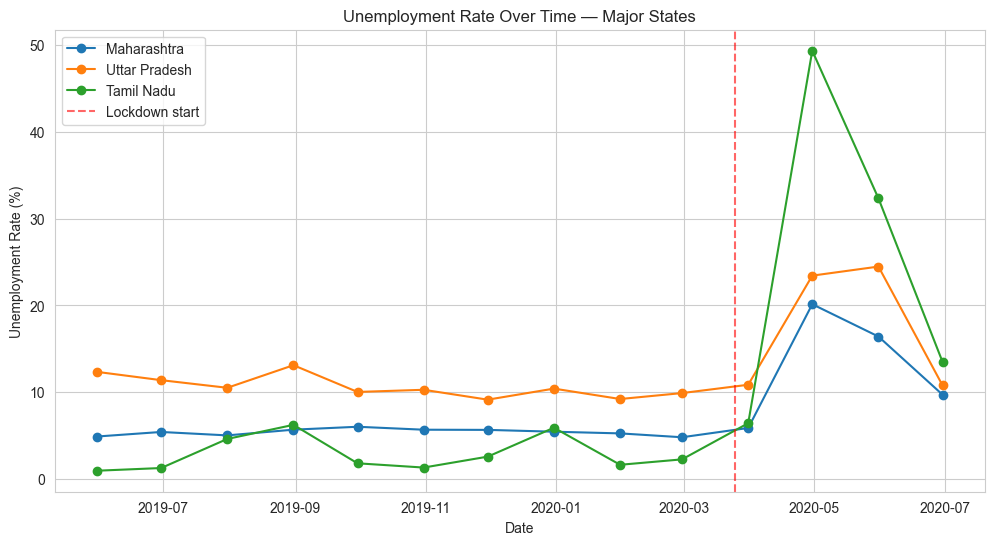

In [8]:
# Time-Series Trend for Major States

major_states = ['Maharashtra', 'Uttar Pradesh', 'Tamil Nadu']
plt.figure(figsize=(12, 6))
for state in major_states:
    sub = Unemp_India[Unemp_India['Region'] == state].groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()
    plt.plot(sub['Date'], sub['Estimated Unemployment Rate (%)'], marker='o', label=state)
plt.axvline(pd.Timestamp('2020-03-25'), color='red', linestyle='--', alpha=0.6, label='Lockdown start')
plt.title('Unemployment Rate Over Time — Major States')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 2\Unemployment_major_states.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

**Observation:** All three states track closely together through most of 2019 with modest seasonal fluctuation, then diverge sharply in April to May 2020, with each state's lockdown-driven spike differing in magnitude depending on its economic structure.

C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_4880\436212584.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')


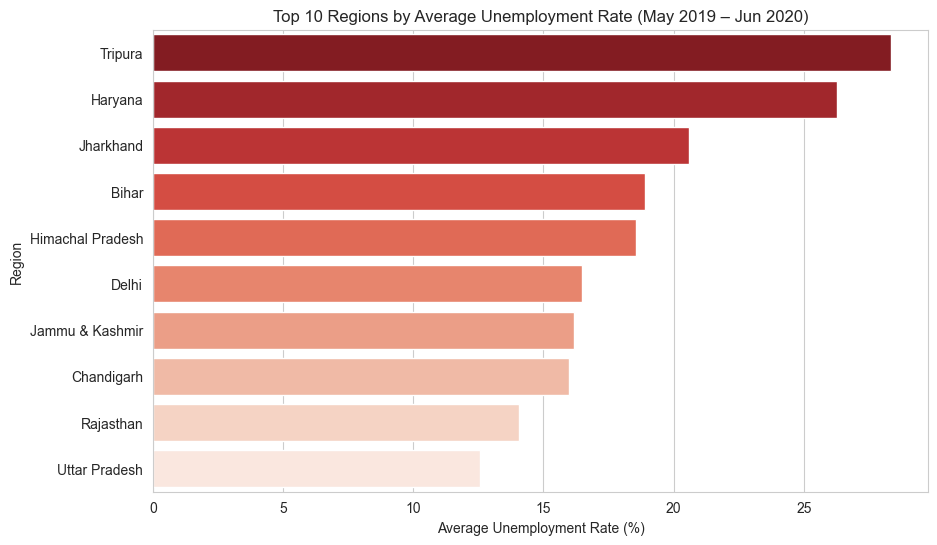

In [9]:
## Top 10 Regions by Average Unemployment Rate

plt.figure(figsize=(10, 6))
top10 = region_avg.head(10)
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')
plt.xlabel('Average Unemployment Rate (%)')
plt.title('Top 10 Regions by Average Unemployment Rate (May 2019 – Jun 2020)')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 2\Unemployment_average_region_rate.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


C:\Users\ThePhantomTrader\AppData\Local\Temp\ipykernel_4880\2727702855.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_avg.index, y=area_avg.values, palette='Set2')


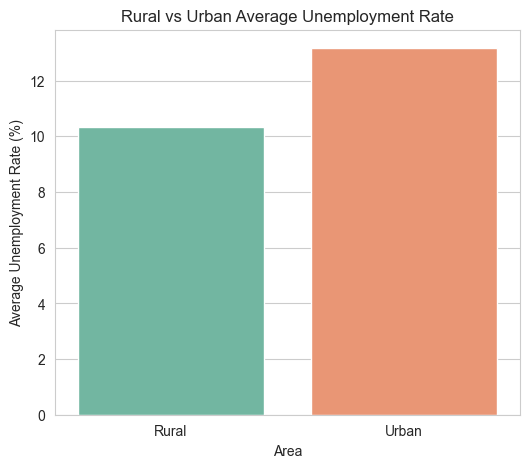

In [10]:
# Rural vs Urban Unemployment

area_avg = Unemp_India.groupby('Area')['Estimated Unemployment Rate (%)'].mean()
print(area_avg)

plt.figure(figsize=(6,5))
sns.barplot(x=area_avg.index, y=area_avg.values, palette='Set2')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Rural vs Urban Average Unemployment Rate')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 2\Unemployment_Rural_Urban.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

**Observation:** Urban unemployment tends to run higher on average than rural unemployment over this period, plausibly reflecting greater reliance on formal-sector jobs and services that were more directly disrupted by lockdown restrictions.

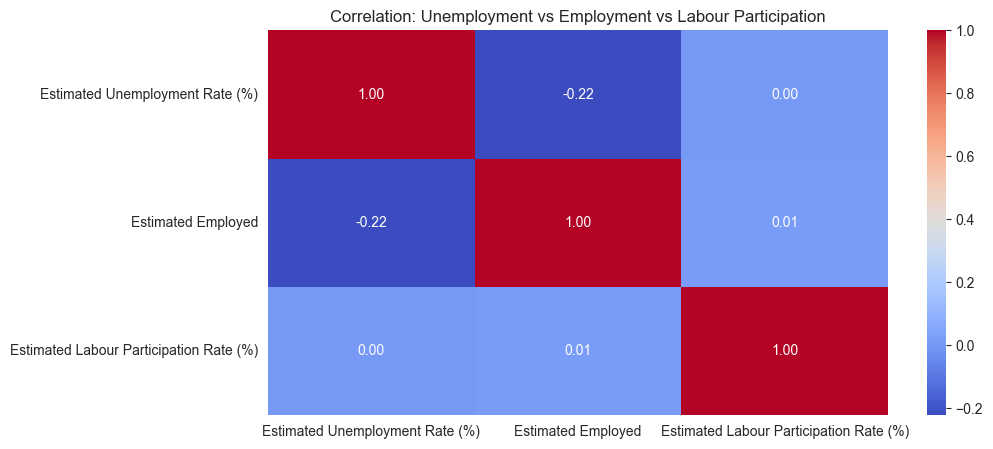

In [11]:
# Correlation Heatmap
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr = Unemp_India[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Unemployment vs Employment vs Labour Participation')
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 2\Unemployment_correlation.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

**Observation:** Unemployment rate shows a weak-to-moderate negative correlation with estimated employed counts. Its relationship with labour participation rate is comparatively weak, suggesting the 2020 unemployment surge was driven mainly by job losses rather than changes in workforce participation.

In [12]:
# Pre-COVID vs Post-COVID Comparison

lockdown_date = pd.Timestamp('2020-03-25')
pre_covid = Unemp_India[Unemp_India['Date'] < lockdown_date]
post_covid = Unemp_India[Unemp_India['Date'] >= lockdown_date]

comparison = pd.DataFrame({
    'Pre-COVID (May 2019–Mar 2020)': [
        pre_covid['Estimated Unemployment Rate (%)'].mean(),
        pre_covid['Estimated Employed'].mean(),
        pre_covid['Estimated Labour Participation Rate (%)'].mean()
    ],
    'Post-COVID (Apr–Jun 2020)': [
        post_covid['Estimated Unemployment Rate (%)'].mean(),
        post_covid['Estimated Employed'].mean(),
        post_covid['Estimated Labour Participation Rate (%)'].mean()
    ]
}, index=['Avg Unemployment Rate (%)', 'Avg Estimated Employed', 'Avg Labour Participation Rate (%)'])
comparison


,Pre-COVID (May 2019–Mar 2020),Post-COVID (Apr–Jun 2020)
Avg Unemployment Rate (%),9.509534e+00,1.777436e+01
Avg Estimated Employed,7.466028e+06,6.517203e+06
Avg Labour Participation Rate (%),4.388612e+01,3.933005e+01


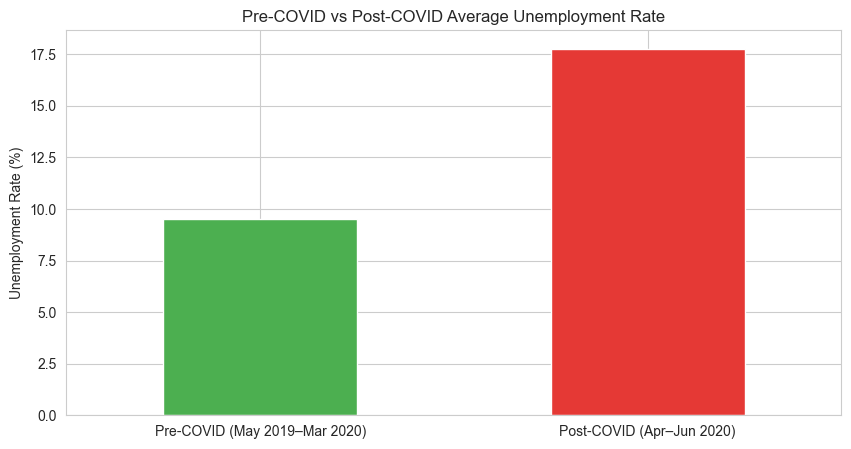

In [13]:
comparison.loc['Avg Unemployment Rate (%)'].plot(kind='bar', color=['#4CAF50', '#E53935'])
plt.ylabel('Unemployment Rate (%)')
plt.title('Pre-COVID vs Post-COVID Average Unemployment Rate')
plt.xticks(rotation=0)
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\Oasis Infobyte\TASK 2\Unemployment_pre_post_covid.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

**Observation:** With nearly a full year of pre-COVID baseline data (May 2019–March 2020) to compare against, the post lockdown period (April–June 2020) shows a dramatic increase in average unemployment rate alongside a drop in estimated employed counts a clear, sustained labour market shock rather than a brief blip.


# Summary of Findings

- Unemployment rates were relatively stable through 2019 and early 2020, then spiked sharply starting **April 2020**, immediately after the COVID-19 lockdown.
- The spike was **not uniform** across states some regions experienced far larger increases than others.
- **Urban unemployment** ran higher on average than rural unemployment across the period.
- Labour participation rate was not strongly correlated with unemployment rate, indicating the surge reflected genuine job losses rather than people leaving/entering the workforce.
- Having nearly a full year of pre-COVID data makes the post-lockdown shock especially clear and statistically meaningful compared to a shorter baseline.